# causal-ai CLI Tutorial

This tutorial shows how to analyse causal test results using the `causal-ai` command-line interface — no Python required beyond installation.

> **Assumption:** Data collection has already been completed and you have a cluster data directory containing:
> - `dag.dot` — the causal DAG
> - `runtime_data_*.csv` — collected experimental observations
> - `causal_tests_*.json` — test definitions
> - `causal_test_results_*.json` — CTF test outcomes
>
> See `examples/digits_dann/` or `examples/action_dann/` for data collection scripts. For help defining your causal DAG and generating test cases, refer to the [Causal Testing Framework documentation](https://causal-testing-framework.readthedocs.io/en/latest/?badge=latest).

---

This tutorial uses pre-collected data from `examples/action_dann/data/` so no HPC access is required to follow along.

In [1]:
import subprocess
import sys
from pathlib import Path
from IPython.display import Image, display

# Helper to run a causal-ai CLI command and print its output
def run(args):
    result = subprocess.run(
        [sys.executable, "-m", "causal_ai"] + args,
        capture_output=True, text=True,
        cwd=Path("__file__").resolve().parent.parent,
    )
    print(result.stdout)
    if result.returncode != 0:
        print(result.stderr)

---

## 1. Summarise Results for a Single Cluster

The `summary` command reads a cluster data directory and prints a pass/fail/skip breakdown of all causal tests.

In [2]:
run(["summary", "examples/action_dann/data/stanage"])

Cluster directory: examples\action_dann\data\stanage
  Total tests:   32
  Passed:        24
  Failed:        8
  Skipped:       0

  Failed tests:
    - seed _||_ test_target_acc
    - fp_precision --> test_target_acc
    - fp_precision --> test_source_acc
    - training_time_seconds _||_ evaluation_time_seconds | ['fp_precision', 'batch_size']
    - batch_size --> training_time_seconds
    - optimiser_type --> training_time_seconds
    - batch_size --> evaluation_time_seconds
    - adaptation_method --> test_target_acc



Add `--json` for structured output, useful for piping into other tools or saving reports:

In [3]:
run(["summary", "examples/action_dann/data/stanage", "--json"])

Cluster directory: examples\action_dann\data\stanage
  Total tests:   32
  Passed:        24
  Failed:        8
  Skipped:       0

  Failed tests:
    - seed _||_ test_target_acc
    - fp_precision --> test_target_acc
    - fp_precision --> test_source_acc
    - training_time_seconds _||_ evaluation_time_seconds | ['fp_precision', 'batch_size']
    - batch_size --> training_time_seconds
    - optimiser_type --> training_time_seconds
    - batch_size --> evaluation_time_seconds
    - adaptation_method --> test_target_acc

{
  "total": 32,
  "passed": 24,
  "failed_count": 8,
  "skipped_count": 0,
  "failed_tests": [
    "seed _||_ test_target_acc",
    "fp_precision --> test_target_acc",
    "fp_precision --> test_source_acc",
    "training_time_seconds _||_ evaluation_time_seconds | ['fp_precision', 'batch_size']",
    "batch_size --> training_time_seconds",
    "optimiser_type --> training_time_seconds",
    "batch_size --> evaluation_time_seconds",
    "adaptation_method --> test_ta

---

## 2. Compare Results Across Clusters

The `compare` command takes a parent directory containing one subdirectory per cluster and identifies **divergent tests** — hypotheses that held on one cluster but not another, indicating platform-dependent behaviour.

The expected directory structure is:

```
examples/action_dann/data/
├── stanage/
│   ├── dag.dot
│   ├── runtime_data_stanage.csv
│   ├── causal_tests_stanage.json
│   └── causal_test_results_stanage.json
└── bede/
    ├── dag.dot
    ├── runtime_data_bede.csv
    ├── causal_tests_bede.json
    └── causal_test_results_bede.json
```

In [4]:
run(["compare", "examples/action_dann/data"])


[bede]
  Total: 32  Passed: 22  Failed: 10  Skipped: 0
  Failed:
    - seed _||_ test_target_acc
    - fp_precision --> training_time_seconds
    - fp_precision --> evaluation_time_seconds
    - fp_precision --> test_target_acc
    - fp_precision --> test_source_acc
    - training_time_seconds _||_ evaluation_time_seconds | ['batch_size', 'fp_precision']
    - training_time_seconds _||_ test_source_acc | ['batch_size', 'fp_precision', 'optimiser_type']
    - optimiser_type --> training_time_seconds
    - batch_size --> test_target_acc
    - adaptation_method --> test_target_acc

[stanage]
  Total: 32  Passed: 24  Failed: 8  Skipped: 0
  Failed:
    - seed _||_ test_target_acc
    - fp_precision --> test_target_acc
    - fp_precision --> test_source_acc
    - training_time_seconds _||_ evaluation_time_seconds | ['fp_precision', 'batch_size']
    - batch_size --> training_time_seconds
    - optimiser_type --> training_time_seconds
    - batch_size --> evaluation_time_seconds
    - adapt

---

## 3. Visualise Results

The `visualise` command generates:

- **One PNG per causal test** — the full DAG with the tested edge highlighted (green = passed, red = failed, dashed = independence test)
- **`summary.png`** — a heatmap showing pass/fail/skip across all tests at a glance

In [5]:
run([
    "visualise",
    "--dag",     "examples/action_dann/data/stanage/dag.dot",
    "--results", "examples/action_dann/data/stanage/causal_test_results_stanage.json",
    "--output_dir", "output/visualisations",
])

Saved 32 individual test plots to output\visualisations\causal_tests/
Saved summary heatmap to output\visualisations\summary.png



Summary heatmap:


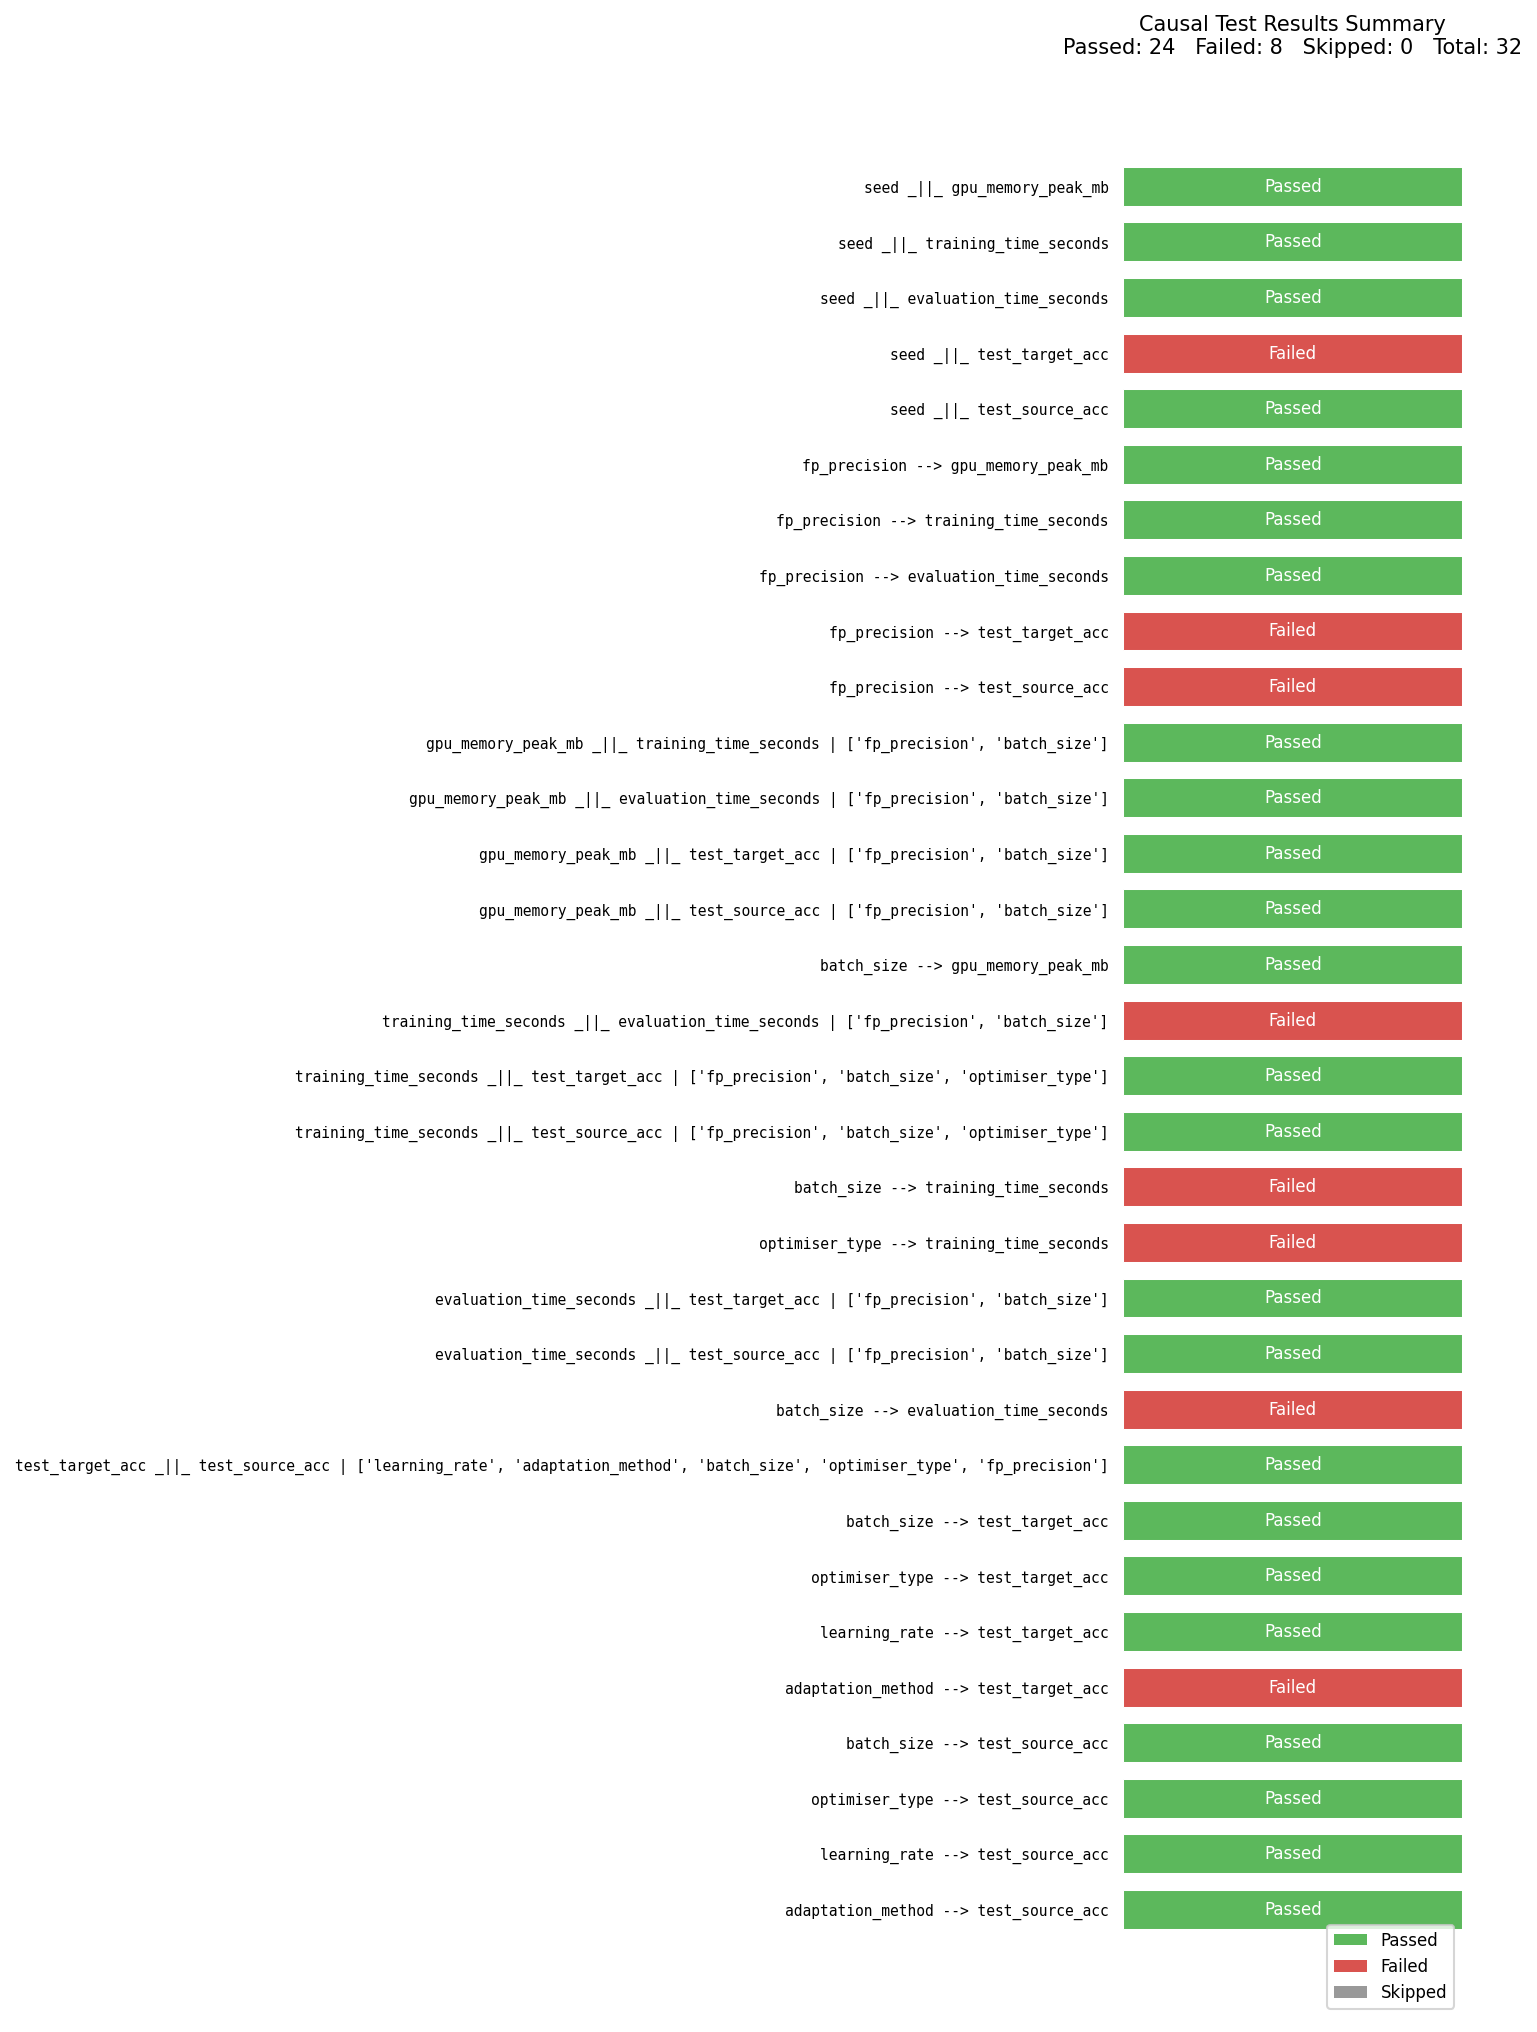

In [6]:
output_dir = Path("__file__").resolve().parent.parent / "output" / "visualisations"

print("Summary heatmap:")
display(Image(filename=str(output_dir / "summary.png")))

35 individual test plots generated. Example:


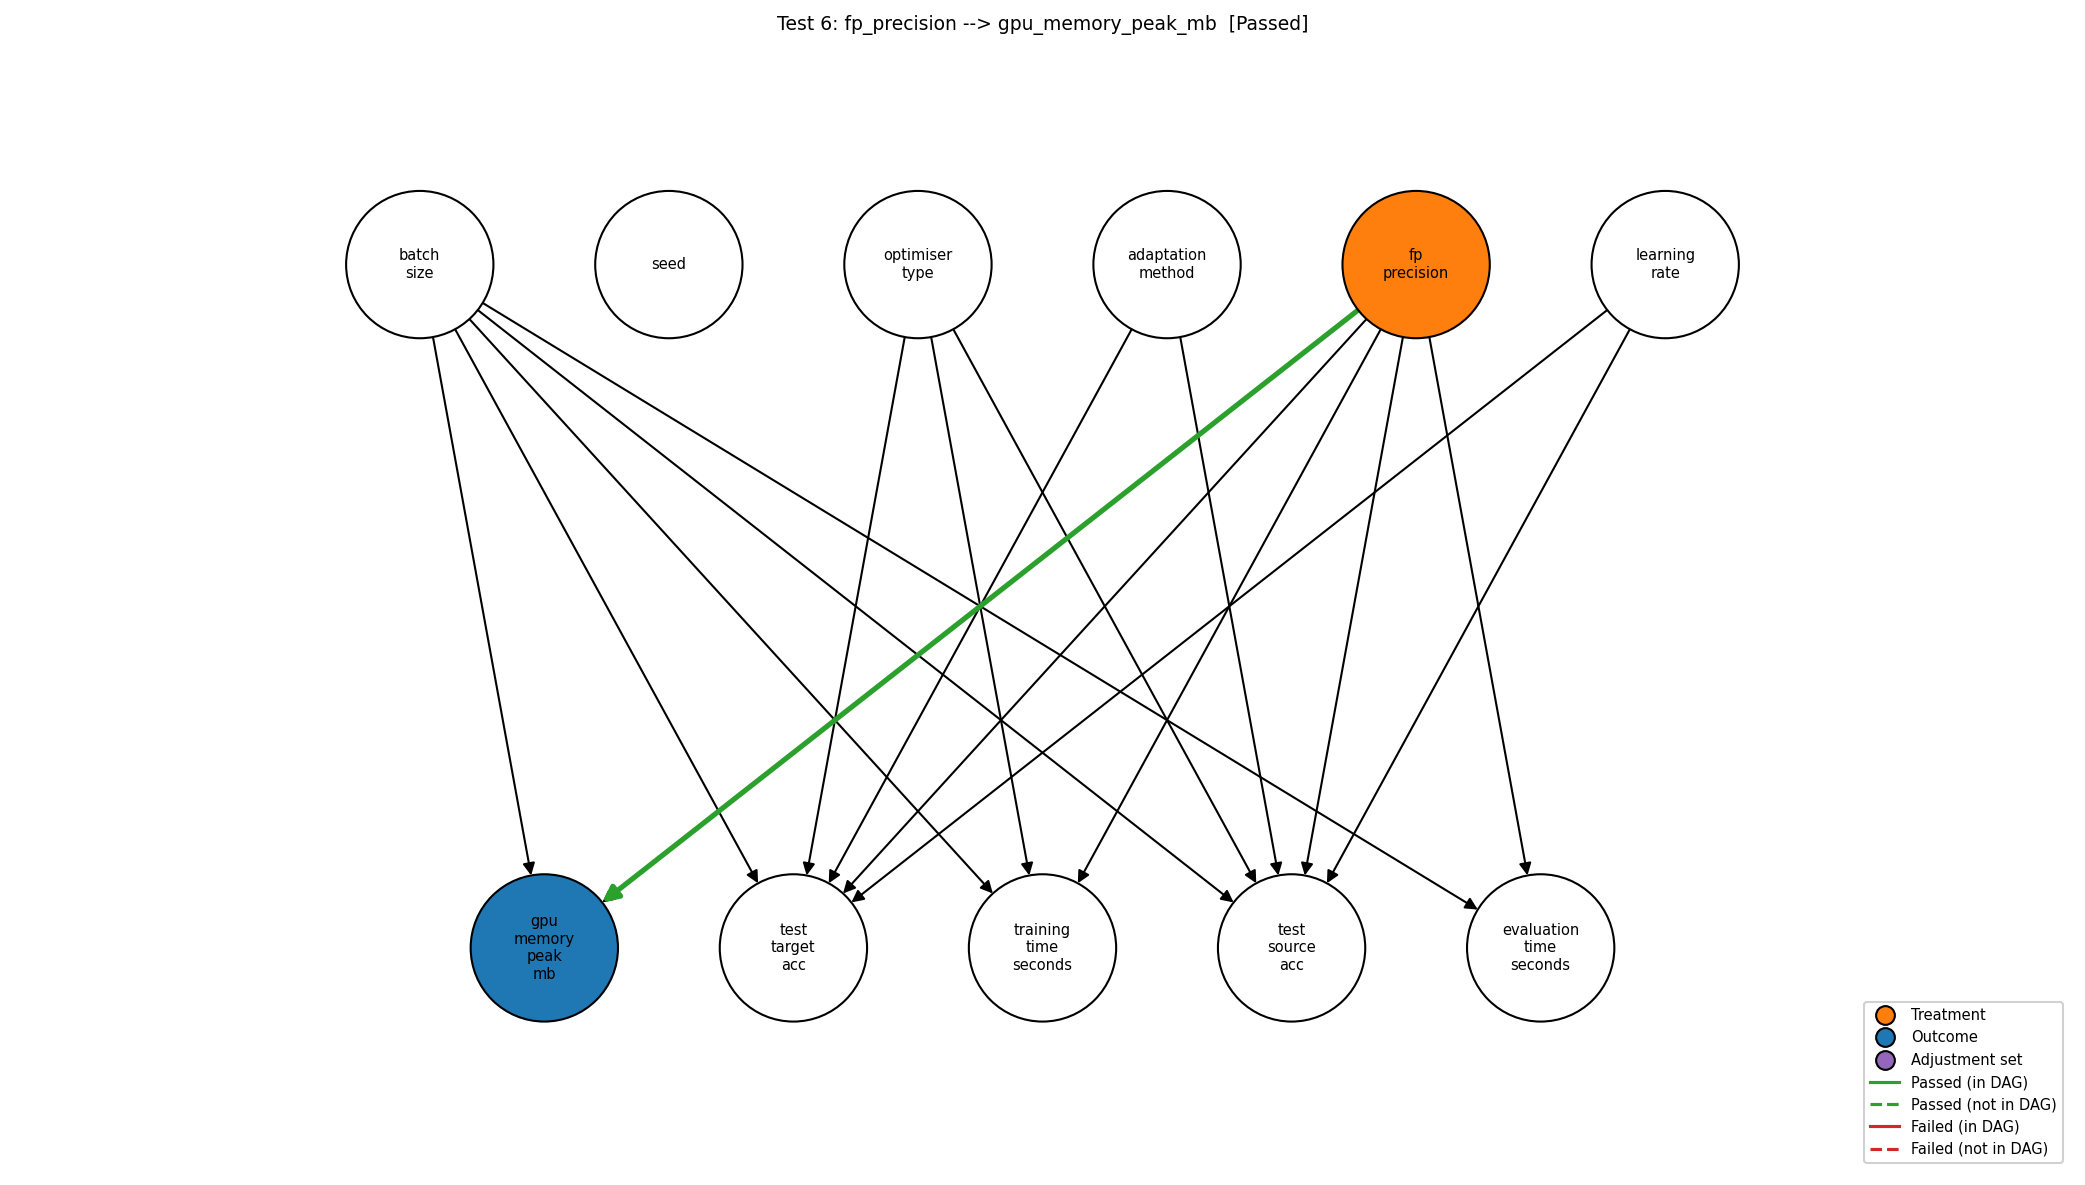

In [7]:
test_plots = sorted((output_dir / "causal_tests").glob("*.png"))
print(f"{len(test_plots)} individual test plots generated. Example:")
display(Image(filename=str(test_plots[5])))

---

## Summary of Commands

```bash
# Summarise a single cluster
python -m causal_ai summary <data_dir>
python -m causal_ai summary <data_dir> --json

# Compare across clusters
python -m causal_ai compare <parent_data_dir>
python -m causal_ai compare <parent_data_dir> --json

# Visualise
python -m causal_ai visualise --dag <dag.dot> --results <results.json> --output_dir <dir>
```

For further help with causal DAG construction and test generation, see the [Causal Testing Framework documentation](https://causal-testing-framework.readthedocs.io/en/latest/?badge=latest).